In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/splitting-data-indobert/train_clean.csv
/kaggle/input/splitting-data-indobert/test_clean.csv
/kaggle/input/labeling-2-sentimen/Hasil_Labelling_2_Lexicon_Data.csv
/kaggle/input/data-split-indobert/train_clean.csv
/kaggle/input/data-split-indobert/test_clean.csv


In [2]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
import matplotlib.pyplot as plt

In [3]:
# Baca dataset dari CSV
df_train = pd.read_csv('/kaggle/input/data-split-indobert/train_clean.csv')
df_test = pd.read_csv('/kaggle/input/data-split-indobert/test_clean.csv')

In [4]:
df_train

,publish_date,author,Stemmed_Text,Sentiment,Compound_Score
0,2024-08-02 20:26:00,Serly Putri Jumbadi - detikJogja,jogja gubernur daerah istimewa yogyakarta diy ...,1,0.045662
1,2024-09-16 11:01:00,Welly Jasrial Tanjung - detikSumbagsel,palembang menteri pariwisata ekonomi kreatif m...,1,0.029762
2,2024-06-26 20:15:00,Ilyas Fadilah - detikFinance,jakarta menteri bumn erick thohir nilai tumbuh...,0,-0.021201
3,2024-09-23 17:57:00,"I Wayan Sui Suadnyana, I Wayan Selamat Juniasa...",karangasem pasang calon paslon gusti putu parw...,1,0.052897
4,2023-09-05 19:22:00,Angga Laraspati - detikFinance,jakarta ktt asean gelar jakarta hadir asean in...,1,0.040000
...,...,...,...,...,...
16065,2024-08-13 15:00:00,Novia Aisyah - detikEdu,jakarta organisasi pramuka baden powell mula b...,1,0.069767
16066,2024-08-10 06:00:00,Melati Putri Arsika - detikSumbagsel,daftar isi sejarah hari pramuka agustus sejara...,1,0.043682
16067,2024-12-11 15:47:00,Ayu Dahlia - detikFinance,jakarta usaha bank rakyat indonesia persero tb...,1,0.059880
16068,2024-11-22 16:12:00,Retno Ayuningrum - detikFinance,jakarta perintah terus geber industri hijau du...,1,0.108033


In [5]:
# Check for unique values in the sentiment column
print("Train_Unique sentiment values before mapping:", df_train['Sentiment'].unique())
print("Test_Unique sentiment values before mapping:", df_test['Sentiment'].unique())

Train_Unique sentiment values before mapping: [1 0]
Test_Unique sentiment values before mapping: [0 1]


In [6]:
tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1")
model = TFAutoModelForSequenceClassification.from_pretrained(
    "indobenchmark/indobert-base-p1",
    num_labels=2,  # Update to 2 labels
    hidden_dropout_prob=0.2,  # Tambahkan Dropout
    attention_probs_dropout_prob=0.2  # Dropout pada Self-Attention
)

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

tf_model.h5:   0%|          | 0.00/656M [00:00<?, ?B/s]

All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [7]:
train_texts = df_train['Stemmed_Text'].tolist()
train_labels = df_train['Sentiment'].tolist()
test_texts = df_test['Stemmed_Text'].tolist()
test_labels = df_test['Sentiment'].tolist()

In [8]:
# Tokenize training data
train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=512,
    return_tensors='tf'
)

# Tokenize test data
test_encodings = tokenizer(
    list(test_texts),
    truncation=True,
    padding=True,
    max_length=512,
    return_tensors='tf'
)

In [9]:
# Create TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    train_labels
)).shuffle(1000).batch(16)

# Create TensorFlow datasets
test_dataset = tf.data.Dataset.from_tensor_slices((
    dict(test_encodings),
    test_labels
)).batch(16)

In [10]:
# Compile model
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
metrics = [tf.keras.metrics.SparseCategoricalAccuracy('accuracy')]

model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=metrics
)

In [11]:
# Create a callback to save the model checkpoints
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='model/checkpoint-{epoch:02d}',  # Save model with epoch in the filename
    monitor='val_loss',  # Monitor validation loss
    save_best_only=True,  # Save only the best model
    mode='min',  # Minimize the monitored quantity
    save_weights_only=False,  # Save the entire model
    verbose=1,  # Print messages when saving
    save_format='tf'  # Save in TensorFlow format
)

# Create an early stopping callback
early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=5,  # Number of epochs with no improvement after which training will be stopped
    verbose=1,  # Print messages when stopping
    mode='min',  # Stop when the quantity monitored has stopped decreasing
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity
)

from sklearn.utils.class_weight import compute_class_weight

# Pastikan train_labels sudah berupa array label numerik (0/1), bukan string
class_weight = compute_class_weight('balanced', classes=np.array([0, 1]), y=train_labels)
class_weight = dict(enumerate(class_weight))

print("Class Weight:", class_weight)  # Misalnya {0: 2.5, 1: 1.0}

Class Weight: {0: 1.347476102632903, 1: 0.7949935688136934}


In [12]:
# Train model
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10,
    callbacks=[checkpoint_callback, early_stopping_callback],# Add early stopping callback
    class_weight=class_weight  # Add class weights
)

Epoch 1/10
1005/1005 [==============================] - ETA: 0s - loss: 0.4547 - accuracy: 0.7816
Epoch 1: val_loss improved from inf to 0.41402, saving model to model/checkpoint-01
1005/1005 [==============================] - 1249s 1s/step - loss: 0.4547 - accuracy: 0.7816 - val_loss: 0.4140 - val_accuracy: 0.8066
Epoch 2/10
1005/1005 [==============================] - ETA: 0s - loss: 0.3189 - accuracy: 0.8589
Epoch 2: val_loss improved from 0.41402 to 0.32662, saving model to model/checkpoint-02
1005/1005 [==============================] - 1207s 1s/step - loss: 0.3189 - accuracy: 0.8589 - val_loss: 0.3266 - val_accuracy: 0.8487
Epoch 3/10
1005/1005 [==============================] - ETA: 0s - loss: 0.2355 - accuracy: 0.8983
Epoch 3: val_loss improved from 0.32662 to 0.29807, saving model to model/checkpoint-03
1005/1005 [==============================] - 1207s 1s/step - loss: 0.2355 - accuracy: 0.8983 - val_loss: 0.2981 - val_accuracy: 0.8718
Epoch 4/10
1005/1005 [===================

In [13]:
# Save the trained model and tokenizer
model.save_pretrained("model_base-p1")
tokenizer.save_pretrained("model_base-p1")
print("Model and tokenizer saved to 'model' directory.")

Model and tokenizer saved to 'model' directory.


In [14]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification

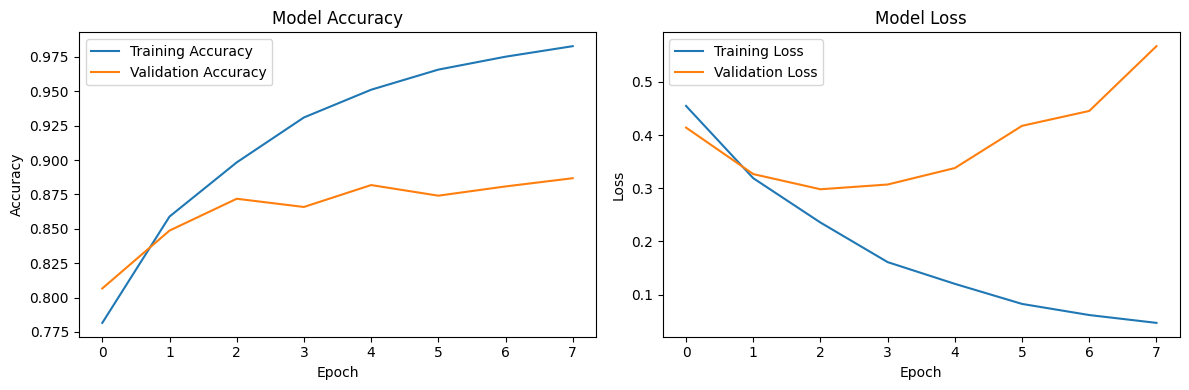

In [15]:
# Visualize training history
plt.figure(figsize=(12, 4))

# Plot training & validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
# Load the saved model and tokenizer using os.path.join
model_dir = os.path.join("model_base-p1")
model = TFAutoModelForSequenceClassification.from_pretrained(model_dir)
tokenizer = AutoTokenizer.from_pretrained(model_dir)

Some layers from the model checkpoint at model_base-p1 were not used when initializing TFBertForSequenceClassification: ['dropout_37']
- This IS expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertForSequenceClassification were initialized from the model checkpoint at model_base-p1.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertForSequenceClassification for predictions without further training.


In [17]:
# Get predictions
logits = model.predict(dict(test_encodings)).logits
y_pred = np.argmax(logits, axis=1)

126/126 [==============================] - 88s 680ms/step


In [18]:
# Calculate metrics
accuracy = accuracy_score(test_labels, y_pred)
precision = precision_score(test_labels, y_pred, average='weighted')
recall = recall_score(test_labels, y_pred, average='weighted')
f1 = f1_score(test_labels, y_pred, average='weighted')

# Print results
print("\nModel Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Print detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(test_labels, y_pred, target_names=['negatif', 'positif']))

# Optional: Print some example predictions
print("\nExample Predictions:")
for i in range(10):  # Show first 5 examples
    text = test_texts[i]
    true_label = "positif" if test_labels[i] == 1 else "negatif"
    pred_label = "positif" if y_pred[i] == 1 else "negatif"
    print(f"\nText: {text[:100]}...")  # Show first 100 characters
    print(f"True Label: {true_label}")
    print(f"Predicted Label: {pred_label}")


Model Evaluation Metrics:
Accuracy: 0.8718
Precision: 0.8739
Recall: 0.8718
F1-Score: 0.8724

Detailed Classification Report:
              precision    recall  f1-score   support

     negatif       0.81      0.86      0.84      1536
     positif       0.91      0.88      0.89      2482

    accuracy                           0.87      4018
   macro avg       0.86      0.87      0.87      4018
weighted avg       0.87      0.87      0.87      4018


Example Predictions:

Text: denpasar cabai rawit jadi komoditas utama sumbang inflasi gabung dua kota kota denpasar singaraja ma...
True Label: negatif
Predicted Label: negatif

Text: jakarta menteri uang sri mulyani indrawati tanggap realisasi tumbuh ekonomi kuartal ii capai year on...
True Label: positif
Predicted Label: positif

Text: jakarta menteri laut ikan sakti wahyu trenggono kenal ikan jade perch komoditas potensial dibudidaya...
True Label: positif
Predicted Label: positif

Text: kulon progo edar kabar tabrak sepeda motor vs mob